# 02  -  Delivery Performance  *(primary business case)*

> **Management question: where and when are deliveries late, and what does it cost us?**

This is Business Case 3, the one the whole warehouse was designed around. Everything
here reads from the **marts** layer  -  no CSV, no raw, no recomputed definitions. If a
number here is wrong, it is wrong in a tested dbt model, and it is wrong everywhere
consistently.

Structure:

1. **WHERE**  -  which states, regions and routes
2. **WHEN**  -  which months, and whether it is improving
3. **WHERE THE TIME GOES**  -  approval, seller handover, or carrier
4. **WHAT IT COSTS**  -  review score and revenue exposed
5. **THE PROMISE ITSELF**  -  is the estimate wrong, or is delivery slow?

In [2]:
# warehouse.py lives at the repository root so the notebooks and the Streamlit
# dashboard share one definition of which datasets to read. Walk up from the
# working directory to find it, so the notebook runs the same whether it is
# opened in Jupyter or executed headless by `make analyse`.
import sys, pathlib
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "warehouse.py").exists())
sys.path.insert(0, str(_root))

import pandas as pd
import matplotlib.pyplot as plt

from warehouse import q, marts, staging, raw, style_charts, describe_connection, SNAPSHOT_DATE

style_charts()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

print(describe_connection())

/Users/timkoo/miniconda3/envs/bd-m2-g7/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.6.0)/charset_normalizer (3.5.1) doesn't match a supported version!
  warnings.warn(


project=olist-group7  location=US  target=dev
marts dataset=dbt_TK_marts
analytical snapshot date=2018-10-17


In [3]:
# Headline numbers first, so every chart below has a baseline to be read against.
headline = q(f"""
    select
        count(*)                                                    as delivered_orders,
        countif(is_late)                                            as late_orders,
        round(safe_divide(countif(is_late), count(*)), 4)           as late_rate,
        round(approx_quantiles(total_delivery_days, 100)[offset(50)], 1) as median_delivery_days,
        round(approx_quantiles(total_delivery_days, 100)[offset(90)], 1) as p90_delivery_days,
        round(sum(late_order_revenue), 2)                           as revenue_delivered_late,
        round(safe_divide(sum(late_order_revenue), sum(order_revenue)), 4) as late_revenue_share,
        round(avg(case when is_late then review_score end), 2)      as avg_review_when_late,
        round(avg(case when not is_late then review_score end), 2)  as avg_review_when_on_time
    from {marts('fct_orders')}
    where is_delivered and not is_excluded_from_kpis and delay_vs_promise_days is not null
""")

h = headline.iloc[0]
print(f"Delivered orders analysed : {h.delivered_orders:,}")
print(f"Late rate                 : {h.late_rate:.1%}")
print(f"Median delivery time      : {h.median_delivery_days} days")
print(f"90th percentile           : {h.p90_delivery_days} days")
print(f"Revenue delivered late    : R$ {h.revenue_delivered_late:,.0f} ({h.late_revenue_share:.1%} of revenue)")
print(f"Review score, on time     : {h.avg_review_when_on_time}")
print(f"Review score, late        : {h.avg_review_when_late}")
print(f"Satisfaction penalty      : {h.avg_review_when_on_time - h.avg_review_when_late:.2f} stars")

/Users/timkoo/miniconda3/envs/bd-m2-g7/lib/python3.11/site-packages/google/cloud/bigquery/client.py:613: UserWarning: Cannot create BigQuery Storage client, the dependency google-cloud-bigquery-storage is not installed.
  warnings.warn(


Delivered orders analysed : 96,470.0
Late rate                 : 6.8%
Median delivery time      : 10.2 days
90th percentile           : 23.1 days
Revenue delivered late    : R$ 985,924 (7.5% of revenue)
Review score, on time     : 4.29
Review score, late        : 2.27
Satisfaction penalty      : 2.02 stars


## 1. WHERE are deliveries late?

### 1a. By destination state

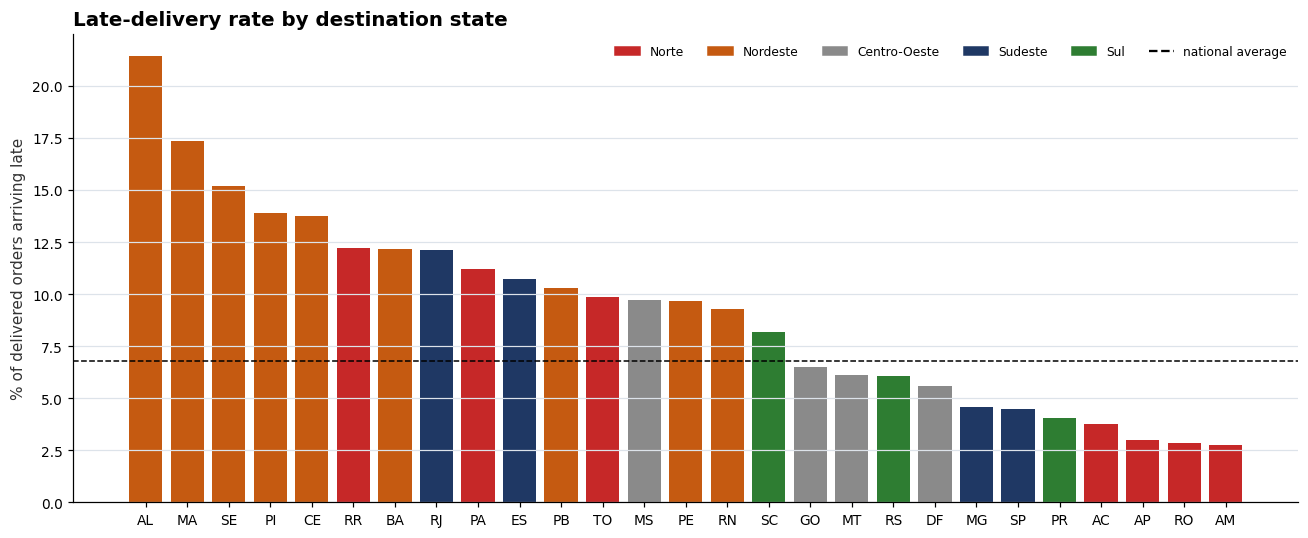

,customer_state,customer_region,delivered_orders,late_orders,late_rate,revenue
0,AL,Nordeste,397,85,0.2141,78856.0
1,MA,Nordeste,720,125,0.1736,117322.0
2,SE,Nordeste,336,51,0.1518,56750.0
3,PI,Nordeste,476,66,0.1387,84721.0
4,CE,Nordeste,1281,176,0.1374,219989.0
5,RR,Norte,41,5,0.1220,7057.0
6,BA,Nordeste,3254,396,0.1217,493354.0
7,RJ,Sudeste,12351,1496,0.1211,1759512.0
8,PA,Norte,946,106,0.1121,174471.0
9,ES,Sudeste,1996,214,0.1072,268733.0


In [4]:
by_state = q(f"""
    select
        customer_state,
        customer_region,
        sum(delivered_orders)                                        as delivered_orders,
        sum(late_orders)                                             as late_orders,
        round(safe_divide(sum(late_orders), sum(delivered_orders)), 4) as late_rate,
        round(sum(delivered_revenue), 0)                             as revenue
    from {marts('agg_delivery_by_route')}
    group by customer_state, customer_region
    having delivered_orders >= 30
    order by late_rate desc
""")

fig, ax = plt.subplots(figsize=(12, 5))
colors = {"Norte": "#c62828", "Nordeste": "#c55a11", "Centro-Oeste": "#8a8a8a",
          "Sudeste": "#1f3864", "Sul": "#2e7d32"}
ax.bar(by_state.customer_state, by_state.late_rate * 100,
       color=[colors.get(r, "#8a8a8a") for r in by_state.customer_region])
ax.axhline(by_state.late_orders.sum() / by_state.delivered_orders.sum() * 100,
           color="black", linestyle="--", linewidth=1, label="national average")
ax.set_title("Late-delivery rate by destination state")
ax.set_ylabel("% of delivered orders arriving late")
ax.legend()
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
ax.legend(handles + [plt.Line2D([0], [0], color="black", linestyle="--")],
          list(colors) + ["national average"], ncol=6, fontsize=8)
plt.tight_layout(); plt.show()

display(by_state.head(12))

### 1b. By route  -  origin matters as much as destination

Almost all Olist sellers are in the Southeast, so a distant destination is really a
long route. Separating the two tells us whether to address the carrier lane or the
seller's location.

In [5]:
routes = q(f"""
    select
        delivery_route, seller_region, customer_region,
        delivered_orders, late_orders, late_rate,
        median_delivery_days, p90_delivery_days,
        round(delivered_revenue, 0) as revenue,
        review_score_penalty_when_late
    from {marts('agg_delivery_by_route')}
    where is_reportable
    order by late_orders desc
    limit 20
""")
display(routes)

print("\nWorst routes by late RATE (volume-filtered):")
display(routes.sort_values("late_rate", ascending=False).head(10)
        [["delivery_route", "delivered_orders", "late_rate", "median_delivery_days", "revenue"]])

,delivery_route,seller_region,customer_region,delivered_orders,late_orders,late_rate,median_delivery_days,p90_delivery_days,revenue,review_score_penalty_when_late
0,SP -> SP,Sudeste,Sudeste,30729,1428,0.0465,6.54,14.25,3521496.0,1.707
1,SP -> RJ,Sudeste,Sudeste,8154,1152,0.1413,12.83,30.88,1064151.0,2.355
2,SP -> MG,Sudeste,Sudeste,7437,393,0.0528,10.75,20.75,926522.0,1.936
3,SP -> BA,Sudeste,Nordeste,2307,297,0.1287,17.67,32.13,311663.0,1.757
4,SP -> RS,Sudeste,Sul,3596,238,0.0662,13.88,27.04,438906.0,2.048
5,SP -> SC,Sudeste,Sul,2326,222,0.0954,13.83,27.00,302610.0,1.951
6,SP -> ES,Sudeste,Sudeste,1459,180,0.1234,13.58,25.92,184502.0,1.718
7,SP -> PR,Sudeste,Sul,3115,138,0.0443,11.08,21.21,391923.0,1.639
8,SP -> CE,Sudeste,Nordeste,969,133,0.1373,18.33,34.00,150077.0,2.071
9,PR -> RJ,Sul,Sudeste,970,117,0.1206,14.00,32.92,147093.0,2.419



Worst routes by late RATE (volume-filtered):


,delivery_route,delivered_orders,late_rate,median_delivery_days,revenue
19,SP -> AL,255,0.2392,22.96,41354.0
14,SP -> MA,492,0.1890,19.50,67254.0
1,SP -> RJ,8154,0.1413,12.83,1064151.0
8,SP -> CE,969,0.1373,18.33,150077.0
3,SP -> BA,2307,0.1287,17.67,311663.0
6,SP -> ES,1459,0.1234,13.58,184502.0
9,PR -> RJ,970,0.1206,14.00,147093.0
18,SP -> PA,683,0.1201,20.92,112813.0
10,SP -> PE,1130,0.0982,15.92,157922.0
5,SP -> SC,2326,0.0954,13.83,302610.0


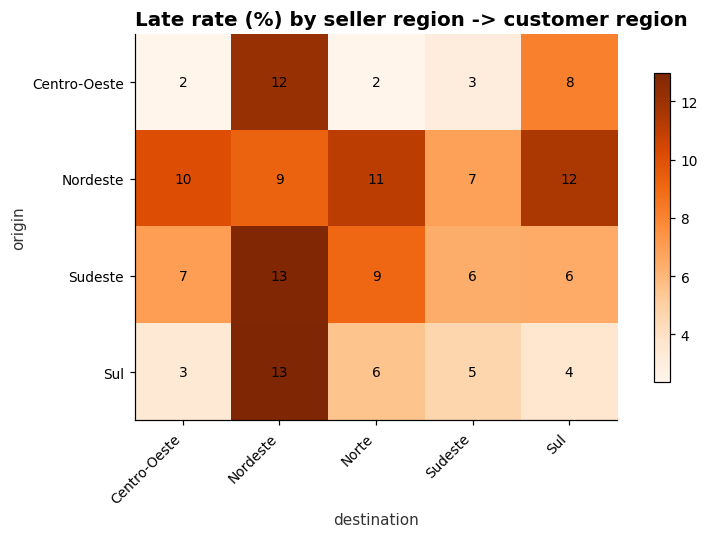

In [6]:
# Region-to-region matrix: the clearest single picture of the WHERE question.
matrix = q(f"""
    select
        seller_region, customer_region,
        sum(delivered_orders)                                          as orders,
        round(safe_divide(sum(late_orders), sum(delivered_orders)), 4)  as late_rate
    from {marts('agg_delivery_by_route')}
    group by seller_region, customer_region
    having orders >= 30
""")

pivot = matrix.pivot(index="seller_region", columns="customer_region", values="late_rate")
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values * 100, cmap="Oranges")
ax.set_xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)), pivot.index)
ax.set_title("Late rate (%) by seller region -> customer region")
ax.set_xlabel("destination"); ax.set_ylabel("origin")
ax.grid(False)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f"{v*100:.0f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

## 2. WHEN are deliveries late?

Bucketed by **purchase** month, not delivery month: the customer's question is "if I
order now, what happens to me?".

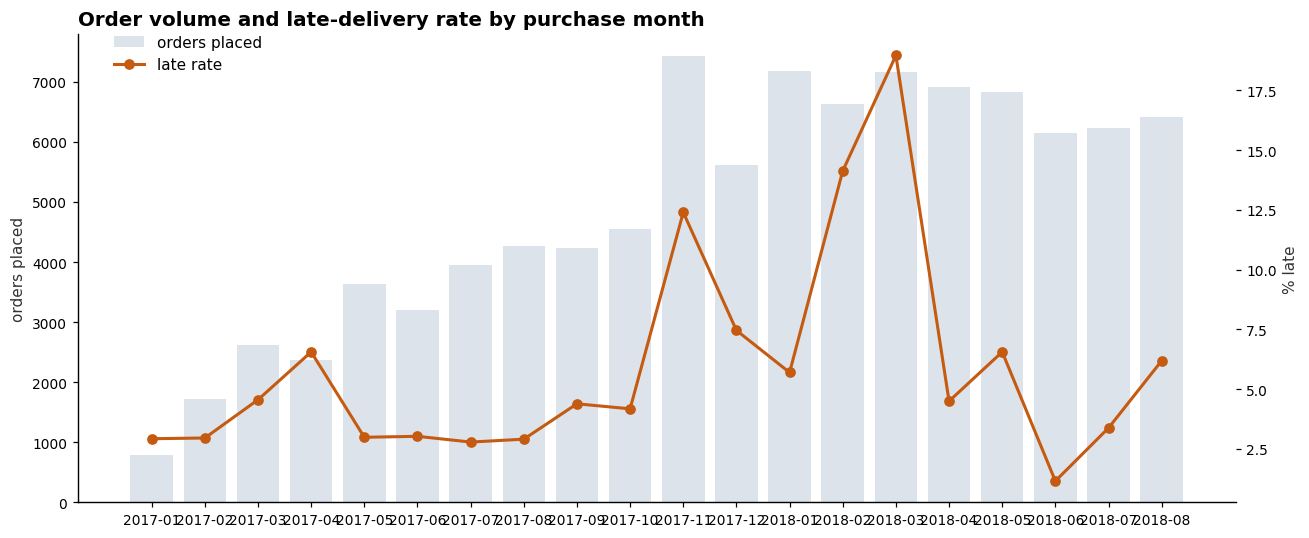

Sparse edge months excluded from the chart above:


,year_month,orders_placed,late_rate
0,2016-09,2,1.0000
1,2016-10,293,0.0075
2,2016-12,1,0.0000
23,2018-09,1,NaN


In [7]:
monthly = q(f"""
    select
        year_month, month_start_date, is_in_analysis_window,
        orders_placed, orders_delivered, late_orders, late_rate,
        median_delivery_days, p90_delivery_days,
        median_approval_days, median_handover_days, median_transit_days,
        avg_review_score, late_rate_mom_change
    from {marts('agg_delivery_monthly')}
    order by month_start_date
""")

usable = monthly[monthly.is_in_analysis_window & (monthly.orders_placed >= 500)]

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(usable.year_month, usable.orders_placed, color="#dde3ea", label="orders placed")
ax1.set_ylabel("orders placed"); ax1.grid(False)
ax2 = ax1.twinx()
ax2.plot(usable.year_month, usable.late_rate * 100, color="#c55a11",
         marker="o", linewidth=2, label="late rate")
ax2.set_ylabel("% late"); ax2.grid(False)
ax1.set_title("Order volume and late-delivery rate by purchase month")
plt.xticks(rotation=90)
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.95))
plt.tight_layout(); plt.show()

print("Sparse edge months excluded from the chart above:")
display(monthly[~monthly.index.isin(usable.index)][["year_month", "orders_placed", "late_rate"]])

In [8]:
# Is it getting better or worse? Answered with a number, not an impression.
first_half = usable.head(len(usable) // 2)
second_half = usable.tail(len(usable) // 2)
print(f"Late rate, first half of the window : {first_half.late_orders.sum() / first_half.orders_delivered.sum():.1%}")
print(f"Late rate, second half              : {second_half.late_orders.sum() / second_half.orders_delivered.sum():.1%}")
print()
print("Worst months by late rate:")
display(usable.nlargest(5, "late_rate")[["year_month", "orders_placed", "late_rate", "median_delivery_days"]])

Late rate, first half of the window : 3.7%
Late rate, second half              : 8.2%

Worst months by late rate:


,year_month,orders_placed,late_rate,median_delivery_days
17,2018-03,7168,0.1896,13.33
16,2018-02,6625,0.1413,14.25
13,2017-11,7423,0.1240,12.67
14,2017-12,5620,0.0746,13.13
6,2017-04,2377,0.0656,12.71


## 3. WHERE DOES THE TIME GO?

Total delivery time decomposed into the three stages we control differently:
payment approval, the seller's own fulfilment, and the carrier. These three findings
lead to three completely different recommendations, which is why the model stores
them separately.

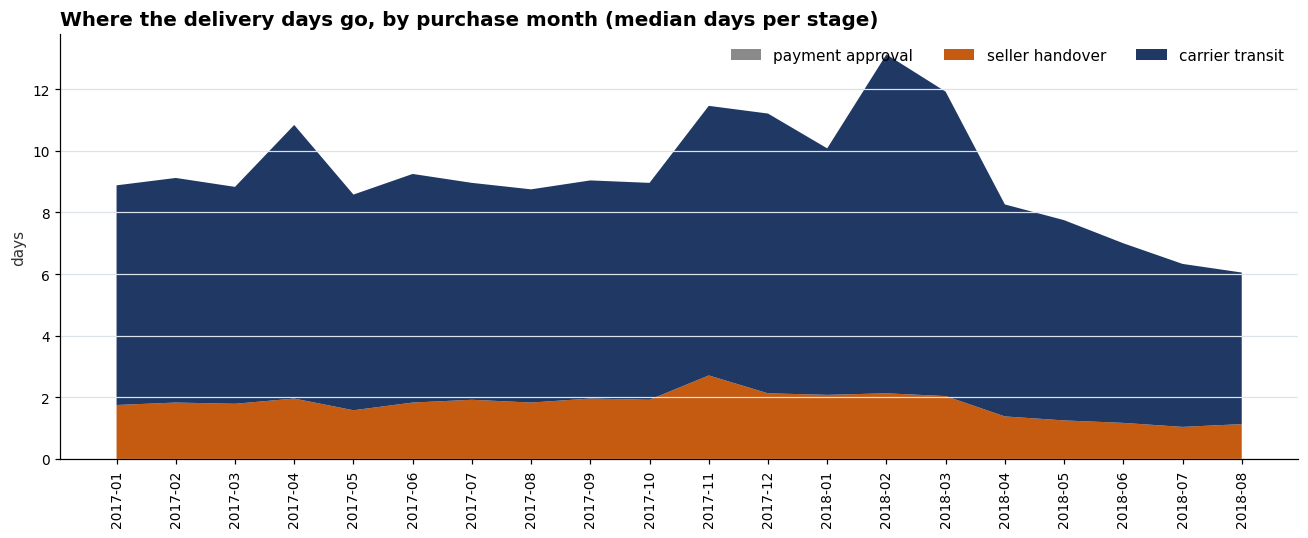

 approval:  0.00 days  ( 0.0% of total)
 handover:  1.79 days  (17.5% of total)
  transit:  7.08 days  (69.3% of total)


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(
    usable.year_month,
    usable.median_approval_days,
    usable.median_handover_days,
    usable.median_transit_days,
    labels=["payment approval", "seller handover", "carrier transit"],
    colors=["#8a8a8a", "#c55a11", "#1f3864"],
)
ax.set_title("Where the delivery days go, by purchase month (median days per stage)")
ax.set_ylabel("days"); ax.legend(loc="upper right", ncol=3)
plt.xticks(rotation=90); plt.tight_layout(); plt.show()

stages = q(f"""
    select
        round(approx_quantiles(approval_days, 100)[offset(50)], 2)         as median_approval_days,
        round(approx_quantiles(seller_handover_days, 100)[offset(50)], 2)  as median_handover_days,
        round(approx_quantiles(carrier_transit_days, 100)[offset(50)], 2)  as median_transit_days,
        round(approx_quantiles(total_delivery_days, 100)[offset(50)], 2)   as median_total_days
    from {marts('fct_orders')}
    where is_delivered and not is_excluded_from_kpis and delay_vs_promise_days is not null
""").iloc[0]

for stage in ["approval", "handover", "transit"]:
    days = stages[f"median_{stage}_days"]
    print(f"{stage:>9}: {days:5.2f} days  ({days / stages.median_total_days:5.1%} of total)")

## 4. WHAT DOES LATENESS COST?

### 4a. Satisfaction

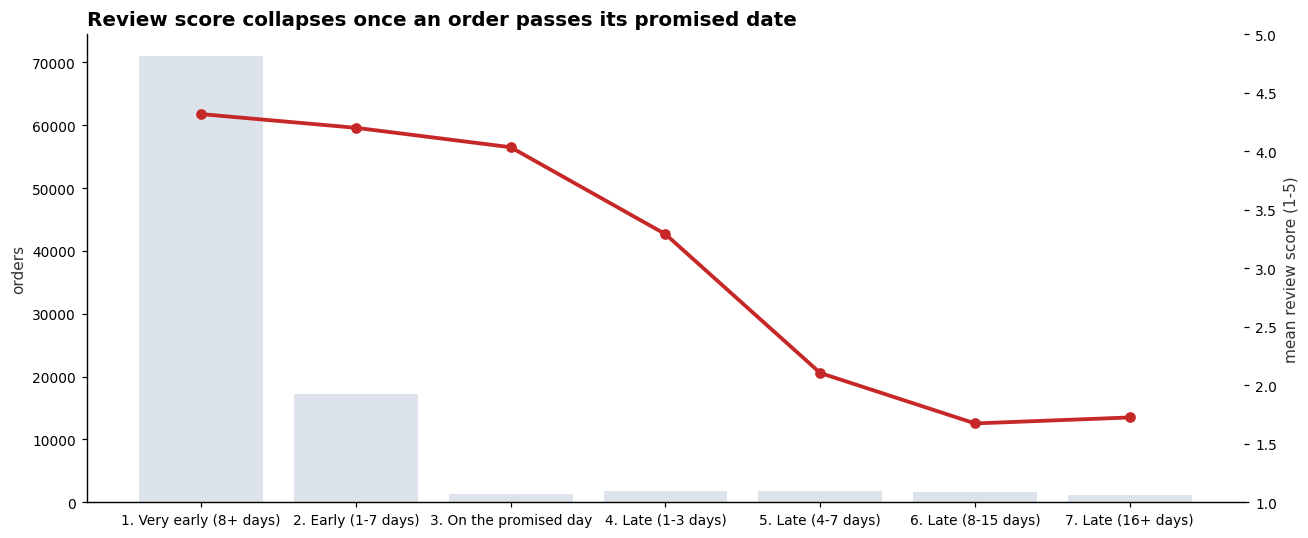

,lateness_bucket,orders,avg_review_score,revenue
0,1. Very early (8+ days),70929,4.317,9769875.0
1,2. Early (1-7 days),17234,4.200,2214527.0
2,3. On the promised day,1280,4.034,170975.0
3,4. Late (1-3 days),1852,3.291,248584.0
4,5. Late (4-7 days),1748,2.105,269935.0
5,6. Late (8-15 days),1601,1.674,251337.0
6,7. Late (16+ days),1180,1.725,183510.0


In [10]:
buckets = q(f"""
    select
        lateness_bucket,
        count(*)                      as orders,
        round(avg(review_score), 3)   as avg_review_score,
        round(sum(order_revenue), 0)  as revenue
    from {marts('fct_orders')}
    where is_delivered and not is_excluded_from_kpis and review_score is not null
      and delay_vs_promise_days is not null
    group by lateness_bucket
    order by lateness_bucket
""")

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(buckets.lateness_bucket, buckets.orders, color="#dde3ea")
ax1.set_ylabel("orders"); ax1.grid(False)
ax2 = ax1.twinx()
ax2.plot(buckets.lateness_bucket, buckets.avg_review_score,
         color="#c62828", marker="o", linewidth=2.5)
ax2.set_ylabel("mean review score (1-5)"); ax2.set_ylim(1, 5); ax2.grid(False)
ax1.set_title("Review score collapses once an order passes its promised date")
plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()

display(buckets)

### 4b. Controlling for region and category

Before claiming lateness *causes* bad reviews, check that the pattern holds inside a
single state and a single category  -  otherwise we may just be comparing regions with
structurally different logistics.

In [11]:
controlled = q(f"""
    select
        o.customer_state,
        o.is_late,
        count(*)                      as orders,
        round(avg(o.review_score), 3) as avg_review_score
    from {marts('fct_orders')} o
    where o.is_delivered and not o.is_excluded_from_kpis
      and o.review_score is not null
      and o.delay_vs_promise_days is not null
      and o.customer_state in ('SP', 'RJ', 'MG', 'RS', 'BA')
    group by o.customer_state, o.is_late
    order by o.customer_state, o.is_late
""")

# Renamed by VALUE (True / False), not by position. A handful of orders are
# "delivered" with an unknown lateness (see the data dictionary): their
# delivered_at timestamp never arrived even though the status flag did.
# Without the delay_vs_promise_days filter above, is_late would be NULL for
# those rows and the pivot would gain a third, unnamed column -- which a
# positional `pivot.columns = [...]` cannot survive.
pivot = controlled.pivot(index="customer_state", columns="is_late", values="avg_review_score")
pivot = pivot.rename(columns={False: "on time", True: "late"})
pivot["penalty"] = (pivot["on time"] - pivot["late"]).round(2)
display(pivot)
print("\nThe penalty holds WITHIN each state, so it is not simply a regional artefact.")
print("It remains a correlation: state and category are controlled, seller quality is not.")

is_late,on time,late,penalty
customer_state,,,
BA,4.143,2.349,1.79
MG,4.278,2.358,1.92
RJ,4.243,1.914,2.33
RS,4.312,2.206,2.11
SP,4.325,2.549,1.78



The penalty holds WITHIN each state, so it is not simply a regional artefact.
It remains a correlation: state and category are controlled, seller quality is not.


### 4c. Revenue exposed

In [12]:
exposure = q(f"""
    select
        customer_region,
        round(sum(order_revenue), 0)                                as total_revenue,
        round(sum(late_order_revenue), 0)                           as late_revenue,
        round(safe_divide(sum(late_order_revenue), sum(order_revenue)), 4) as late_revenue_share
    from {marts('fct_orders')}
    where is_delivered and not is_excluded_from_kpis and delay_vs_promise_days is not null
    group by customer_region
    order by late_revenue desc
""")
display(exposure)
print(f"\nTotal revenue delivered late: R$ {exposure.late_revenue.sum():,.0f}")

,customer_region,total_revenue,late_revenue,late_revenue_share
0,Sudeste,8648826.0,595764.0,0.0689
1,Nordeste,1497114.0,198777.0,0.1328
2,Sul,1900757.0,111576.0,0.0587
3,Centro-Oeste,846358.0,50658.0,0.0599
4,Norte,327194.0,29150.0,0.0891



Total revenue delivered late: R$ 985,925


## 5. IS THE PROMISE WRONG, OR IS DELIVERY SLOW?

The cheapest fix in this whole analysis may not be logistics at all. If the promised
date is systematically padded or systematically optimistic, correcting the estimate
costs nothing and changes the customer's experience immediately.

Median promise : 24.0 days
Median actual  : 10.2 days
Average slack  : 11.84 days (padded)
Delivered early: 92.4% of orders


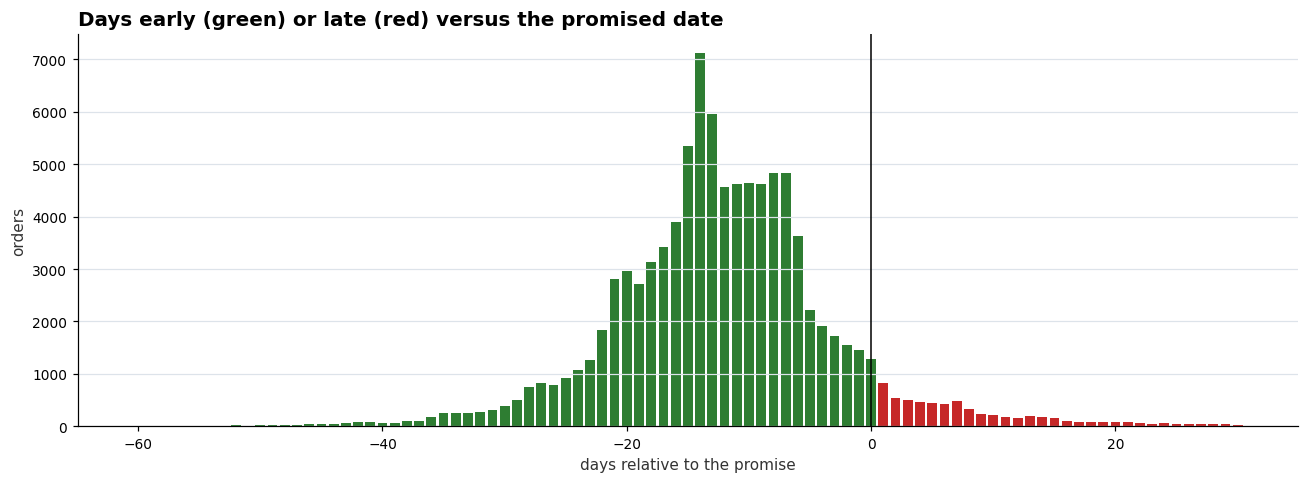

In [13]:
promise = q(f"""
    select
        round(approx_quantiles(promised_delivery_days, 100)[offset(50)], 1) as median_promised_days,
        round(approx_quantiles(total_delivery_days, 100)[offset(50)], 1)    as median_actual_days,
        round(avg(promise_slack_days), 2)                                   as avg_slack_days,
        countif(promise_slack_days > 0)                                     as delivered_early,
        countif(promise_slack_days < 0)                                     as delivered_late,
        count(*)                                                            as orders
    from {marts('fct_orders')}
    where is_delivered and not is_excluded_from_kpis
      and promise_slack_days is not null
""").iloc[0]

print(f"Median promise : {promise.median_promised_days} days")
print(f"Median actual  : {promise.median_actual_days} days")
print(f"Average slack  : {promise.avg_slack_days} days "
      f"({'padded' if promise.avg_slack_days > 0 else 'optimistic'})")
print(f"Delivered early: {promise.delivered_early / promise.orders:.1%} of orders")

dist = q(f"""
    select delay_vs_promise_days, count(*) as orders
    from {marts('fct_orders')}
    where is_delivered and delay_vs_promise_days between -60 and 30
    group by delay_vs_promise_days order by delay_vs_promise_days
""")

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(dist.delay_vs_promise_days, dist.orders,
       color=["#2e7d32" if d <= 0 else "#c62828" for d in dist.delay_vs_promise_days])
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Days early (green) or late (red) versus the promised date")
ax.set_xlabel("days relative to the promise"); ax.set_ylabel("orders")
plt.tight_layout(); plt.show()

## 6. BigQuery cost evidence

The partitioning and clustering benchmark. Dry runs, so nothing is charged and the
result cache cannot flatter the numbers.

In [14]:
from warehouse import bytes_billed

business_query = f"""
    select customer_state, count(*) as orders, avg(total_delivery_days) as avg_days
    from {marts('fct_orders')}
    where order_purchase_date between '2018-01-01' and '2018-03-31'
    group by customer_state
"""

full_scan_query = f"""
    select customer_state, count(*) as orders, avg(total_delivery_days) as avg_days
    from {marts('fct_orders')}
    where format_date('%Y-%m', order_purchase_date) between '2018-01' and '2018-03'
    group by customer_state
"""

pruned = bytes_billed(business_query)
unpruned = bytes_billed(full_scan_query)

print(f"Filtering the partition column directly : {pruned:>12,} bytes")
print(f"Wrapping it in FORMAT_DATE()            : {unpruned:>12,} bytes")
print(f"Partition pruning saves                 : {1 - pruned / unpruned:>12.1%}")
print()
print("This is the concrete reason models never wrap order_purchase_date in a")
print("function: doing so disables partition pruning and scans the whole table.")

Filtering the partition column directly :      419,520 bytes
Wrapping it in FORMAT_DATE()            :    1,965,100 bytes
Partition pruning saves                 :        78.7%

This is the concrete reason models never wrap order_purchase_date in a
function: doing so disables partition pruning and scans the whole table.


## Insight cards

Fill in from the numbers above. Each needs all five parts  -  an observation without an
action is not a finding.

### Insight 1  -  WHERE
- **Observation:**
- **Interpretation:**
- **Decision:**
- **Expected impact:**
- **Caveat:**

### Insight 2  -  WHEN / stage decomposition
- **Observation:**
- **Interpretation:**
- **Decision:**
- **Expected impact:**
- **Caveat:**

### Insight 3  -  COST
- **Observation:**
- **Interpretation:**
- **Decision:**
- **Expected impact:**
- **Caveat:** Correlational. State and category are controlled; seller quality and
  product mix are not. Validate with an A/B or quasi-experiment before acting at scale.